# 📝 Exercise M4.02

In the previous notebook, we showed that we can add new features based on the
original feature `x` to make the model more expressive, for instance `x ** 2` or
`x ** 3`. In that case we only used a single feature in `data`.

The aim of this notebook is to train a linear regression algorithm on a
dataset with more than a single feature. In such a "multi-dimensional" feature
space we can derive new features of the form `x1 * x2`, `x2 * x3`, etc.
Products of features are usually called "non-linear" or "multiplicative"
interactions between features.

Feature engineering can be an important step of a model pipeline as long as
the new features are expected to be predictive. For instance, think of a
classification model to decide if a patient has risk of developing a heart
disease. This would depend on the patient's Body Mass Index which is defined
as `weight / height ** 2`.

We load the penguins dataset. We first use a set of 3 numerical
features to predict the target, i.e. the body mass of the penguin.

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Note</p>
<p class="last">If you want a deeper overview regarding this dataset, you can refer to the
Appendix - Datasets description section at the end of this MOOC.</p>
</div>

In [15]:
import pandas as pd

penguins = pd.read_csv("../datasets/penguins.csv")

columns = ["Flipper Length (mm)", "Culmen Length (mm)", "Culmen Depth (mm)"]
target_name = "Body Mass (g)"

# Remove lines with missing values for the columns of interest
penguins_non_missing = penguins[columns + [target_name]].dropna()

data = penguins_non_missing[columns]
target = penguins_non_missing[target_name]
data

,Flipper Length (mm),Culmen Length (mm),Culmen Depth (mm)
0,181.0,39.1,18.7
1,186.0,39.5,17.4
2,195.0,40.3,18.0
4,193.0,36.7,19.3
5,190.0,39.3,20.6
...,...,...,...
339,207.0,55.8,19.8
340,202.0,43.5,18.1
341,193.0,49.6,18.2
342,210.0,50.8,19.0


Now it is your turn to train a linear regression model on this dataset. First,
create a linear regression model.

In [16]:
# Write your code here.
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
model = make_pipeline(
    LinearRegression()
)

Execute a cross-validation with 10 folds and use the mean absolute error (MAE)
as metric.

In [17]:
# Write your code here.
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, data, target, cv=10, scoring="neg_mean_absolute_error")
cv_results = pd.DataFrame(cv_results)
cv_results["test_score"] = -cv_results["test_score"]
cv_results[["test_score"]]

,test_score
0,423.713303
1,324.586926
2,300.289045
3,370.387698
4,358.783363
5,288.955700
6,205.460785
7,254.843734
8,320.214739
9,523.478081


Compute the mean and std of the MAE in grams (g). Remember you have to revert
the sign introduced when metrics start with `neg_`, such as in
`"neg_mean_absolute_error"`.

In [18]:
# Write your code here.
print(f"mean absolute error: {cv_results['test_score'].mean():.2f} g +/- {cv_results['test_score'].std():.2f} g")

mean absolute error: 337.07 g +/- 89.46 g


Now create a pipeline using `make_pipeline` consisting of a
`PolynomialFeatures` and a linear regression. Set `degree=2` and
`interaction_only=True` to the feature engineering step. Remember not to
include a "bias" feature (that is a constant-valued feature) to avoid
introducing a redundancy with the intercept of the subsequent linear
regression model.

You may want to use the `.set_output(transform="pandas")` method of the
pipeline to answer the next question.

In [19]:
# Write your code here.
from sklearn.preprocessing import PolynomialFeatures
model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False, interaction_only=True),
    LinearRegression()
).set_output(transform="pandas")
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",True
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


Transform the first 5 rows of the dataset and look at the column names. How
many features are generated at the output of the `PolynomialFeatures` step in
the previous pipeline?

In [20]:
# Write your code here.
model.fit(data, target)
model[0].transform(data[:5])

,Flipper Length (mm),Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm) Culmen Length (mm),Flipper Length (mm) Culmen Depth (mm),Culmen Length (mm) Culmen Depth (mm)
0,181.0,39.1,18.7,7077.1,3384.7,731.17
1,186.0,39.5,17.4,7347.0,3236.4,687.30
2,195.0,40.3,18.0,7858.5,3510.0,725.40
4,193.0,36.7,19.3,7083.1,3724.9,708.31
5,190.0,39.3,20.6,7467.0,3914.0,809.58


Check that the values for the new interaction features are correct for a few
of them.

In [21]:
# Write your code here.
flipper_length_first_sample = 181.0
culmen_depth_first_sample = 18.7
flipper_length_first_sample * culmen_depth_first_sample

3384.7

Use the same cross-validation strategy as done previously to estimate the mean
and std of the MAE in grams (g) for such a pipeline. Compare with the results
without feature engineering.

In [22]:
# Write your code here.
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, data, target, cv=10, scoring="neg_mean_absolute_error")
cv_results = pd.DataFrame(cv_results)
cv_results["test_score"] = -cv_results["test_score"]
print(f"mean absolute error: {cv_results['test_score'].mean():.2f} g +/- {cv_results['test_score'].std():.2f} g")

mean absolute error: 301.79 g +/- 46.74 g



Now let's try to build an alternative pipeline with an adjustable number of
intermediate features while keeping a similar predictive power. To do so, try
using the `Nystroem` transformer instead of `PolynomialFeatures`. Set the
kernel parameter to `"poly"` and `degree` to 2. Adjust the number of
components to be as small as possible while keeping a good cross-validation
performance.

Hint: Use a `ValidationCurveDisplay` with `param_range = np.array([5, 10, 50,
100])` to find the optimal `n_components`.

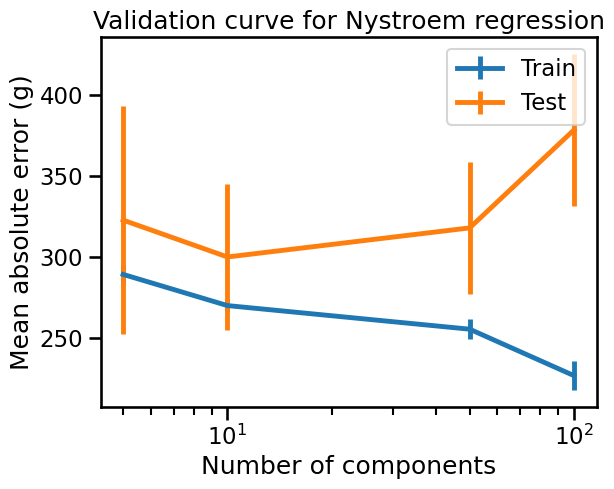

In [23]:
# Write your code here.
import numpy as np
from sklearn.kernel_approximation import Nystroem
from sklearn.model_selection import ValidationCurveDisplay

nystroem_regression = make_pipeline(
    Nystroem(kernel="poly", degree=2, random_state=0),
    LinearRegression()
)

param_range = np.array([5, 10, 50, 100])
disp = ValidationCurveDisplay.from_estimator(
    nystroem_regression,
    data,
    target,
    param_name="nystroem__n_components",
    param_range=param_range,
    negate_score=True,
    cv=10,
    scoring="neg_mean_absolute_error",
    std_display_style="errorbar",
    n_jobs=2
)

_ = disp.ax_.set(
    title="Validation curve for Nystroem regression",
    xlabel="Number of components",
    ylabel="Mean absolute error (g)",
)

How do the mean and std of the MAE for the Nystroem pipeline with optimal
`n_components` compare to the other previous models?

In [24]:
# Write your code here.
nystroem_regression.set_params(nystroem__n_components=10)
cv_results = cross_validate(
    nystroem_regression,
    data,
    target,
    cv=10,
    scoring="neg_mean_absolute_error",
    n_jobs=2,
)
print(
    "Mean absolute error on testing set with nystroem: "
    f"{-cv_results['test_score'].mean():.3f} ± "
    f"{cv_results['test_score'].std():.3f} g"
)

Mean absolute error on testing set with nystroem: 299.824 ± 44.901 g
